In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "2"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
from datetime import datetime

from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# Use TensorFlow's Keras to avoid protobuf import errors
import tensorflow.keras as keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras import optimizers, regularizers
import keras.backend as K

import matplotlib.pyplot as plt




2026-05-07 09:59:38.556026: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778147978.569282      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778147978.573421      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
TRAIN_PATH = "../input/train.csv"
TEST_PATH = "../input/test.csv"
SUBMISSION_NAME = "submissiontry_water.csv"

BATCH_SIZE = 256
EPOCHS = 150  # more epochs for better convergence
LEARNING_RATE = 0.0005
DATASET_SIZE = 200000  # larger sample for improved learning
EARLY_STOP_PATIENCE = 20  # moderate patience for early stopping




In [3]:
datatypes = {
    "key": "str",
    "fare_amount": "float32",
    "pickup_datetime": "str",
    "pickup_longitude": "float32",
    "pickup_latitude": "float32",
    "dropoff_longitude": "float32",
    "dropoff_latitude": "float32",
    "passenger_count": "uint8",
}

trainKaggle = pd.read_csv(
    TRAIN_PATH,
    nrows=DATASET_SIZE,
    dtype=datatypes,
    usecols=[
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count",
    ],
)
testKaggle = pd.read_csv(
    TEST_PATH,
    dtype=datatypes,
    usecols=[
        "key",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count",
    ],
)
testKaggle_original = testKaggle.copy()




In [4]:
train_df, validation_df = train_test_split(trainKaggle, test_size=0.10, random_state=1)
test_df = pd.DataFrame(columns=trainKaggle.columns)




In [5]:
def clean(df):
    print(" Old size: %d" % len(df))
    df = df.dropna(how="any", axis="rows")
    print(" New size after dropna: %d" % len(df))

    df = df[
        (df["dropoff_longitude"] != df["pickup_longitude"])
        & (df["dropoff_latitude"] != df["pickup_latitude"])
    ]
    print(" New size after removing same long lat: %d" % len(df))

    df = df[
        (df["dropoff_longitude"] != 0)
        & (df["pickup_longitude"] != 0)
        & (df["dropoff_latitude"] != 0)
        & (df["pickup_latitude"] != 0)
    ]
    print(" New size after removing 0 long lat: %d" % len(df))

    MinMax = (-74.5, -72.8, 40.5, 41.8)
    df = df[
        (MinMax[0] <= df["pickup_longitude"]) & (df["pickup_longitude"] <= MinMax[1])
    ]
    df = df[
        (MinMax[0] <= df["dropoff_longitude"]) & (df["dropoff_longitude"] <= MinMax[1])
    ]
    df = df[(MinMax[2] <= df["pickup_latitude"]) & (df["pickup_latitude"] <= MinMax[3])]
    df = df[
        (MinMax[2] <= df["dropoff_latitude"]) & (df["dropoff_latitude"] <= MinMax[3])
    ]

    print(" New size after only NYC: %d" % len(df))
    df = df[(0 < df["fare_amount"]) & (df["fare_amount"] <= 50)]

    print(" New size after removing outliers: %d" % len(df))

    df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]
    print(" New size after removing 6=>passenger_count > 0 : %d" % len(df))

    print("Skipping water‑mask removal (disabled).")
    return df


def remove_datapoints_from_water(df):
    return df


def late_night(row):
    return 1 if 0 <= row["hour"] <= 3 else 0


def night(row):
    return 1 if (20 <= row["hour"] <= 23) and (row["weekday"] < 5) else 0


def rush_hour(row):
    return 1 if (16 <= row["hour"] <= 20) and (row["weekday"] < 5) else 0


def manhattan(pickup_lat, pickup_long, dropoff_lat, dropoff_long):
    return np.abs(dropoff_lat - pickup_lat) + np.abs(dropoff_long - pickup_long)


def add_time_features(df):
    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
    df["year"] = df["pickup_datetime"].dt.year
    df["month"] = df["pickup_datetime"].dt.month
    df["day"] = df["pickup_datetime"].dt.day
    df["hour"] = df["pickup_datetime"].dt.hour
    df["weekday"] = df["pickup_datetime"].dt.weekday
    df["night"] = df.apply(lambda x: night(x), axis=1)
    df["late_night"] = df.apply(lambda x: late_night(x), axis=1)
    df["rush_hour"] = df.apply(lambda x: rush_hour(x), axis=1)
    df["pickup_datetime"] = df["pickup_datetime"].astype(str)
    return df


def add_coordinate_features(df):
    df["latdiff"] = df["pickup_latitude"] - df["dropoff_latitude"]
    df["londiff"] = df["pickup_longitude"] - df["dropoff_longitude"]
    return df


def add_distances_features(df):
    lat1 = df["pickup_latitude"]
    lat2 = df["dropoff_latitude"]
    lon1 = df["pickup_longitude"]
    lon2 = df["dropoff_longitude"]
    df["manhattan"] = manhattan(lat1, lon1, lat2, lon2)
    df["distance"] = np.sqrt((lon1 - lon2) ** 2 + (lat1 - lat2) ** 2)
    return df


def output_submission(raw_test, prediction, id_column, prediction_column, file_name):
    df = pd.DataFrame(prediction, columns=[prediction_column])
    df[id_column] = raw_test[id_column].values
    df[[id_column, prediction_column]].to_csv(file_name, index=False)
    print("Output complete")


def plot_loss_accuracy(history):
    plt.figure(figsize=(20, 10))
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title("model loss")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.legend(["train", "test"], loc="upper right")
    plt.show()


def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))




In [6]:
print("Cleaning train and validation dataframes")
train_df = clean(train_df)
validation_df = clean(validation_df)




Cleaning train and validation dataframes
 Old size: 180000
 New size after dropna: 179999
 New size after removing same long lat: 174643
 New size after removing 0 long lat: 174332
 New size after only NYC: 174141
 New size after removing outliers: 171997
 New size after removing 6=>passenger_count > 0 : 171362
Skipping water‑mask removal (disabled).
 Old size: 20000
 New size after dropna: 20000
 New size after removing same long lat: 19409
 New size after removing 0 long lat: 19377
 New size after only NYC: 19349
 New size after removing outliers: 19127
 New size after removing 6=>passenger_count > 0 : 19067
Skipping water‑mask removal (disabled).


In [7]:
print("train_df add_time_features")
train_df = add_time_features(train_df)
print("validation_df add_time_features")
validation_df = add_time_features(validation_df)
print("test_df add_time_features (empty placeholder)")
test_df = add_time_features(test_df)
print("testKaggle add_time_features")
testKaggle = add_time_features(testKaggle)




train_df add_time_features
validation_df add_time_features
test_df add_time_features (empty placeholder)
testKaggle add_time_features


In [8]:
print("train_df add_coordinate_features")
train_df = add_coordinate_features(train_df)
print("validation_df add_coordinate_features")
validation_df = add_coordinate_features(validation_df)
print("test_df add_coordinate_features")
test_df = add_coordinate_features(test_df)
print("testKaggle add_coordinate_features")
testKaggle = add_coordinate_features(testKaggle)




train_df add_coordinate_features
validation_df add_coordinate_features
test_df add_coordinate_features
testKaggle add_coordinate_features


In [9]:
print("train_df add_distances_features")
train_df = add_distances_features(train_df)
print("validation_df add_distances_features")
validation_df = add_distances_features(validation_df)
print("test_df add_distances_features")
test_df = add_distances_features(test_df)
print("testKaggle add_distances_features")
testKaggle = add_distances_features(testKaggle)

print("Done with Adding features")




train_df add_distances_features
validation_df add_distances_features
test_df add_distances_features
testKaggle add_distances_features
Done with Adding features


In [10]:
dropped_columns = ["pickup_datetime"]
train_df = train_df.drop(columns=dropped_columns, errors="ignore")
validation_df = validation_df.drop(columns=dropped_columns, errors="ignore")
test_df = test_df.drop(columns=dropped_columns + ["key"], errors="ignore")
testKaggle_clean = testKaggle.drop(columns=dropped_columns + ["key"], errors="ignore")

print("Done with dropped_columns")




Done with dropped_columns


In [11]:
train_labels = np.log1p(train_df["fare_amount"].values)
validation_labels = np.log1p(validation_df["fare_amount"].values)

train_df = train_df.drop(["fare_amount"], axis=1)
validation_df = validation_df.drop(["fare_amount"], axis=1)

print("Done with Labels")




Done with Labels


In [12]:
scaler = preprocessing.MinMaxScaler()
train_df_scaled = scaler.fit_transform(train_df)
validation_df_scaled = scaler.transform(validation_df)

if test_df.shape[0] > 0:
    test_scaled = scaler.transform(test_df)
else:
    test_scaled = np.empty((0, train_df_scaled.shape[1]))

testKaggle_scaled = scaler.transform(testKaggle_clean)




In [13]:
model = Sequential()
model.add(
    Dense(
        256,
        activation="relu",
        input_dim=train_df_scaled.shape[1],
        activity_regularizer=regularizers.l1(0.00001),
    )
)
model.add(BatchNormalization())
model.add(Dense(128, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(8, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(1))

adam = optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(loss="mean_squared_error", optimizer=adam, metrics=["mae"])

print("Dataset size: %s" % DATASET_SIZE)
print("Epochs: %s" % EPOCHS)
print("Learning rate: %s" % LEARNING_RATE)
print("Batch size: %s" % BATCH_SIZE)
print("Input dimension: %s" % train_df_scaled.shape[1])
print("Features used: %s" % train_df.columns)
model.summary()

early_stop = EarlyStopping(patience=EARLY_STOP_PATIENCE, restore_best_weights=True)

history = model.fit(
    x=train_df_scaled,
    y=train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    validation_data=(validation_df_scaled, validation_labels),
    shuffle=True,
    callbacks=[early_stop],
)




I0000 00:00:1778147991.600165      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset size: 200000
Epochs: 150
Learning rate: 0.0005
Batch size: 256
Input dimension: 17
Features used: Index(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'year', 'month', 'day', 'hour',
       'weekday', 'night', 'late_night', 'rush_hour', 'latdiff', 'londiff',
       'manhattan', 'distance'],
      dtype='object')


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,065 (195.57 KB)

...

Epoch 1/150


I0000 00:00:1778147995.019585     113 service.cc:148] XLA service 0x7f5338017620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778147995.019612     113 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1778147995.281981     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


 91/670 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.7148 - mae: 2.2714

I0000 00:00:1778147996.159389     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


670/670 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 3.9787 - mae: 1.8829 - val_loss: 0.1911 - val_mae: 0.3419
Epoch 2/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1348 - mae: 0.2614 - val_loss: 0.0719 - val_mae: 0.1782
Epoch 3/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0720 - mae: 0.1798 - val_loss: 0.0626 - val_mae: 0.1704
Epoch 4/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0640 - mae: 0.1722 - val_loss: 0.0592 - val_mae: 0.1717
Epoch 5/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0610 - mae: 0.1683 - val_loss: 0.0587 - val_mae: 0.1653
Epoch 6/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0584 - mae: 0.1662 - val_loss: 0.0531 - val_mae: 0.1587
Epoch 7/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0564 - mae: 0.1629 - val_loss: 0.0543 - val_mae: 0.1664
Epoch 8/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0542 - mae: 0.1607 - val_loss: 0.0493 - val_mae: 0.1524
Epoch 9/150
670/670 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss:

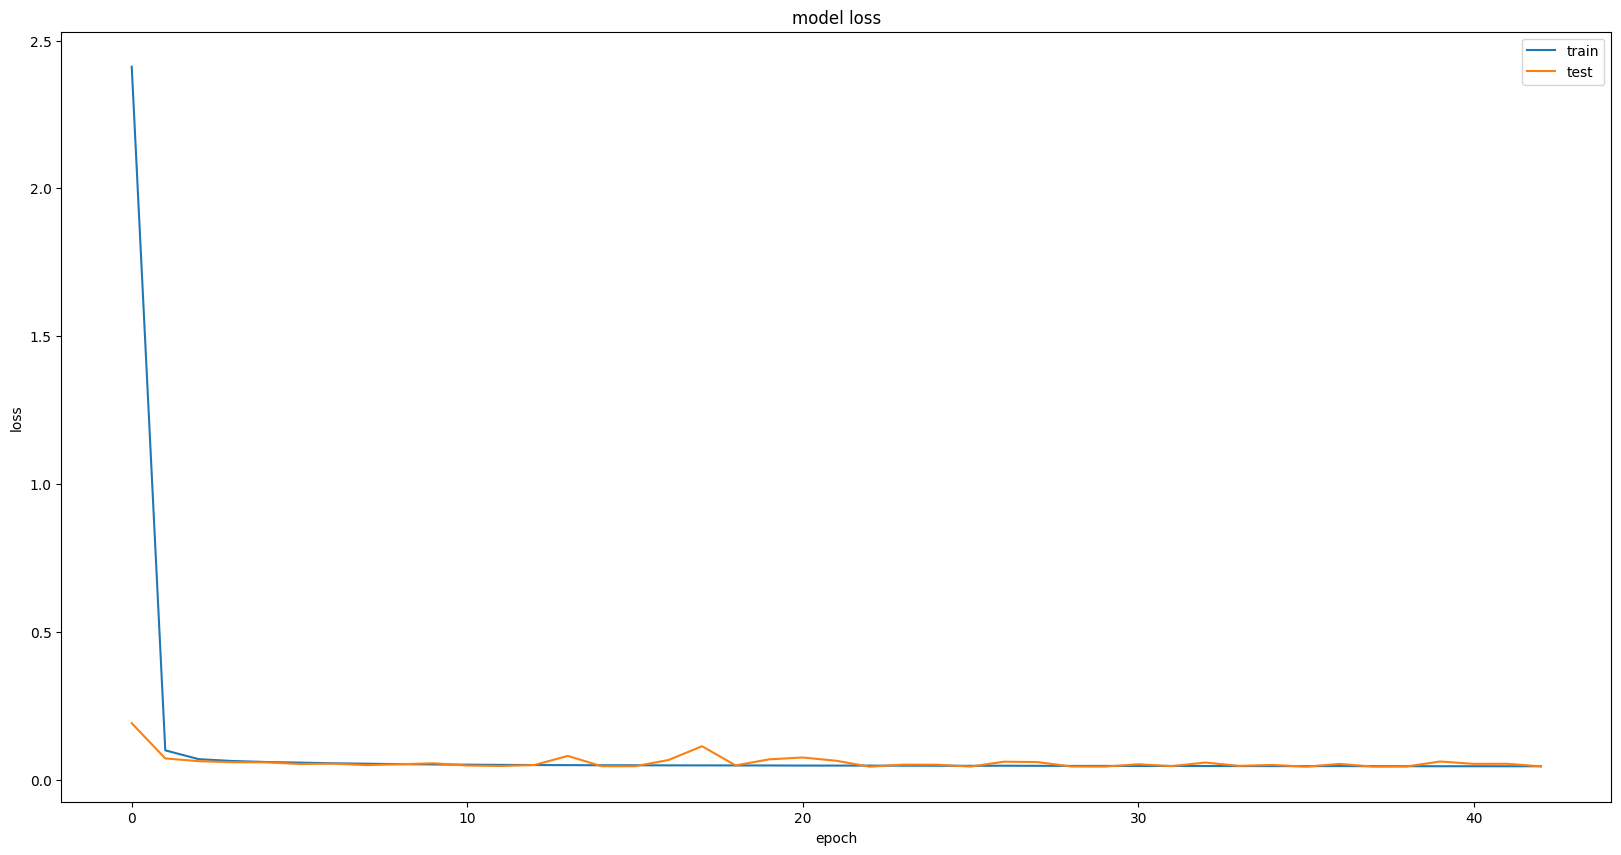

In [14]:
plot_loss_accuracy(history)




In [15]:
predictionKaggle_log = model.predict(
    testKaggle_scaled, batch_size=128, verbose=1
).flatten()
predictionKaggle = np.expm1(predictionKaggle_log)




78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [16]:
output_submission(
    testKaggle_original, predictionKaggle, "key", "fare_amount", SUBMISSION_NAME
)

Output complete
